# Imports and Setup

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../1-Data/heart.csv")

# 1. Dataset info

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [79]:
df.describe().T # trans

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


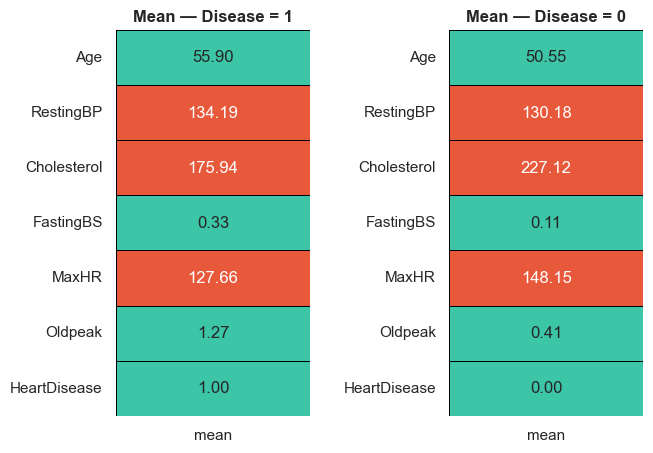

In [80]:
yes = df[df['HeartDisease']==1].describe().T[['mean']]
no  = df[df['HeartDisease']==0].describe().T[['mean']]
fig, axes = plt.subplots(1, 2, figsize=(7, 5))
for ax, data, title in [(axes[0], yes, 'Mean — Disease = 1'),
                        (axes[1], no,  'Mean — Disease = 0')]:
    sns.heatmap(data, annot=True, cmap=COLORS, linewidths=0.4,
                linecolor='black', cbar=False, fmt='.2f', ax=ax)
    ax.set_title(title, fontweight='bold')
fig.tight_layout(pad=2); plt.show()

- Oldpeak: (strongest indicator): x3 higher in disease group
- MaxHR: lower than the normal
- FastingBS: x3 higher than the one doesn't have heart problem
- Age & Resting: slightly higher
- ABNORMAL: Choresterol is much lower for those having heart disease --> Need to see the data.

# 2. Data check

In [81]:
print("Null values:\n",df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Null values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicated rows: 0


In [82]:
print(f'RestingBP = 0: {(df["RestingBP"]==0).sum()} records')

RestingBP = 0: 1 records


In [83]:
zero_cholesterol = df[df['Cholesterol'] == 0].groupby('HeartDisease').size()
print('Number of cases that have Heart Disease by categories')
print(zero_cholesterol)

Number of cases that have Heart Disease by categories
HeartDisease
0     20
1    152
dtype: int64


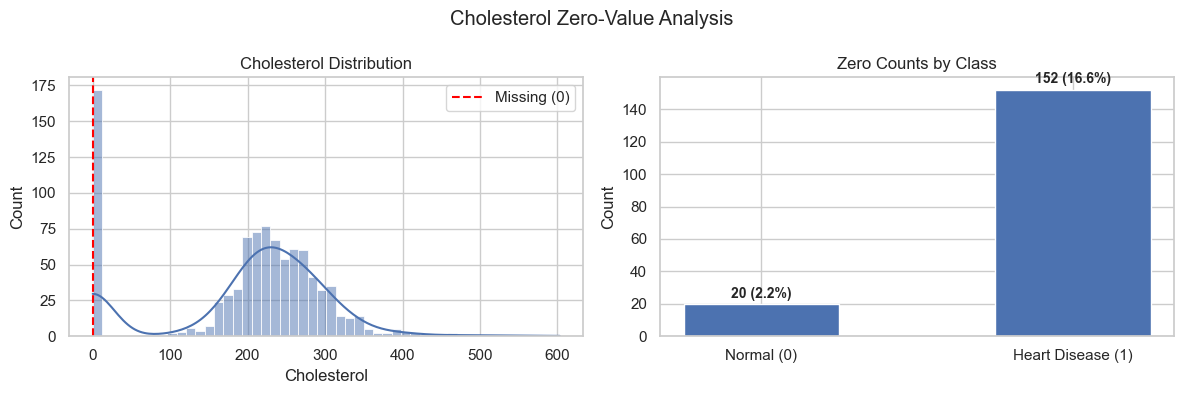

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Cholesterol Zero-Value Analysis")

sns.histplot(df['Cholesterol'], bins=50, kde=True, ax=axes[0])
axes[0].axvline(0, color='red', ls='--', label='Missing (0)')
axes[0].set_title("Cholesterol Distribution")
axes[0].legend()

n_zeros = [20, 152]
total_samples = 918

bars = axes[1].bar(
    ['Normal (0)', 'Heart Disease (1)'],
    n_zeros,
    width=0.5,
)

axes[1].set_title("Zero Counts by Class", )
axes[1].set_ylabel("Count")

# Hiển thị % theo tổng 734
for bar in bars:
    height = bar.get_height()
    percent = height / total_samples * 100

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height} ({percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

# 3. Univariate

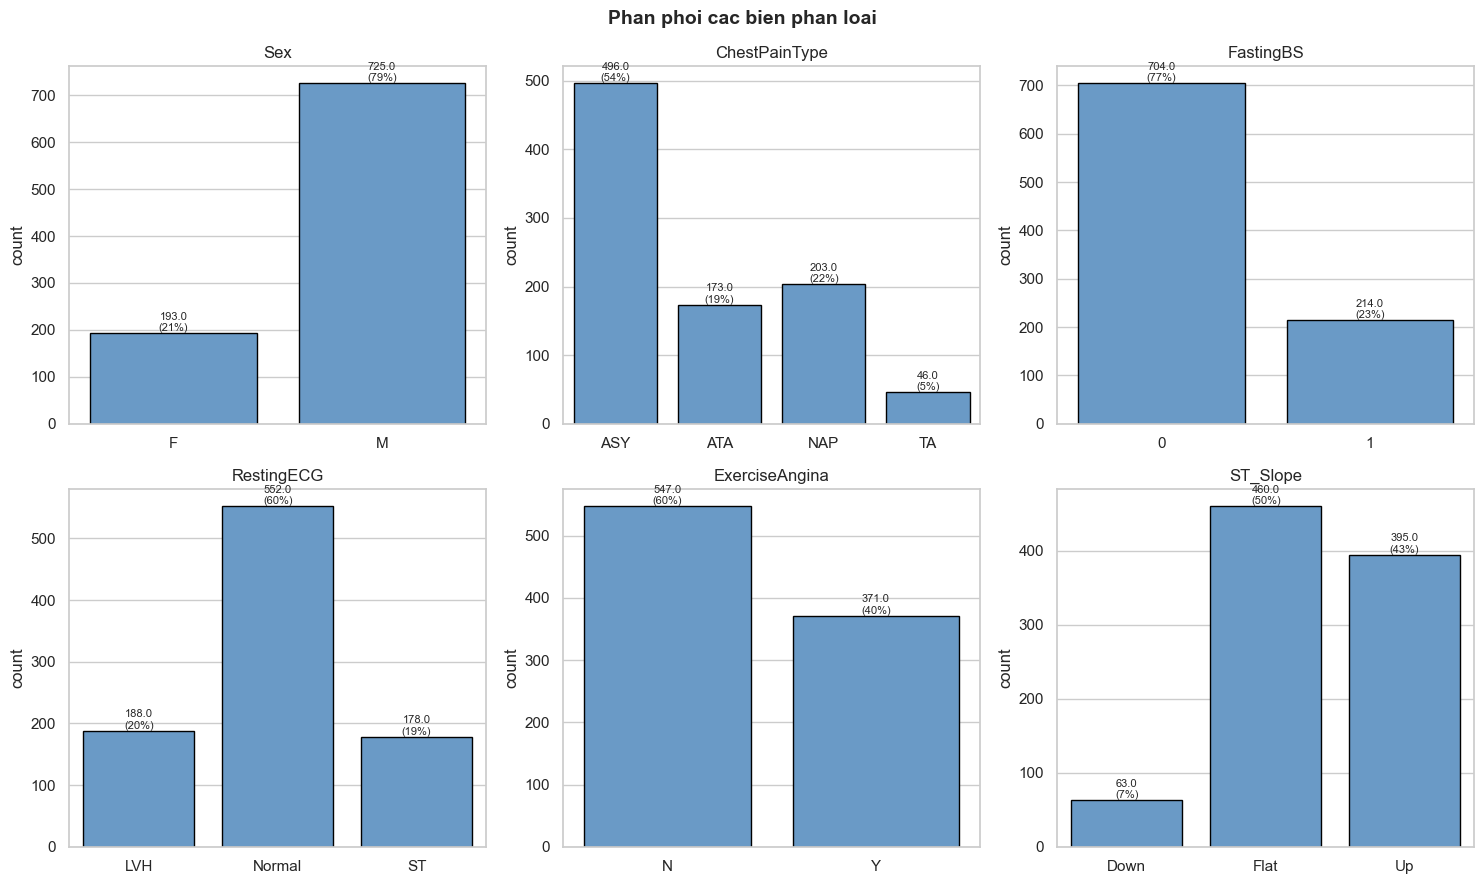

In [85]:
cat_cols = ['Sex','ChestPainType','FastingBS','RestingECG','ExerciseAngina','ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Phan phoi cac bien phan loai', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    order = sorted(df[col].astype(str).unique())
    sns.countplot(x=col, data=df, order=order, color='#5B9BD5',
                  edgecolor='black', ax=ax)
    for p in ax.patches:
        pct = p.get_height() / len(df) * 100
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height()}\n({pct:.0f}%)',
                        (p.get_x()+p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=8)
    ax.set_title(col); ax.set_xlabel('')

plt.tight_layout()
plt.show()


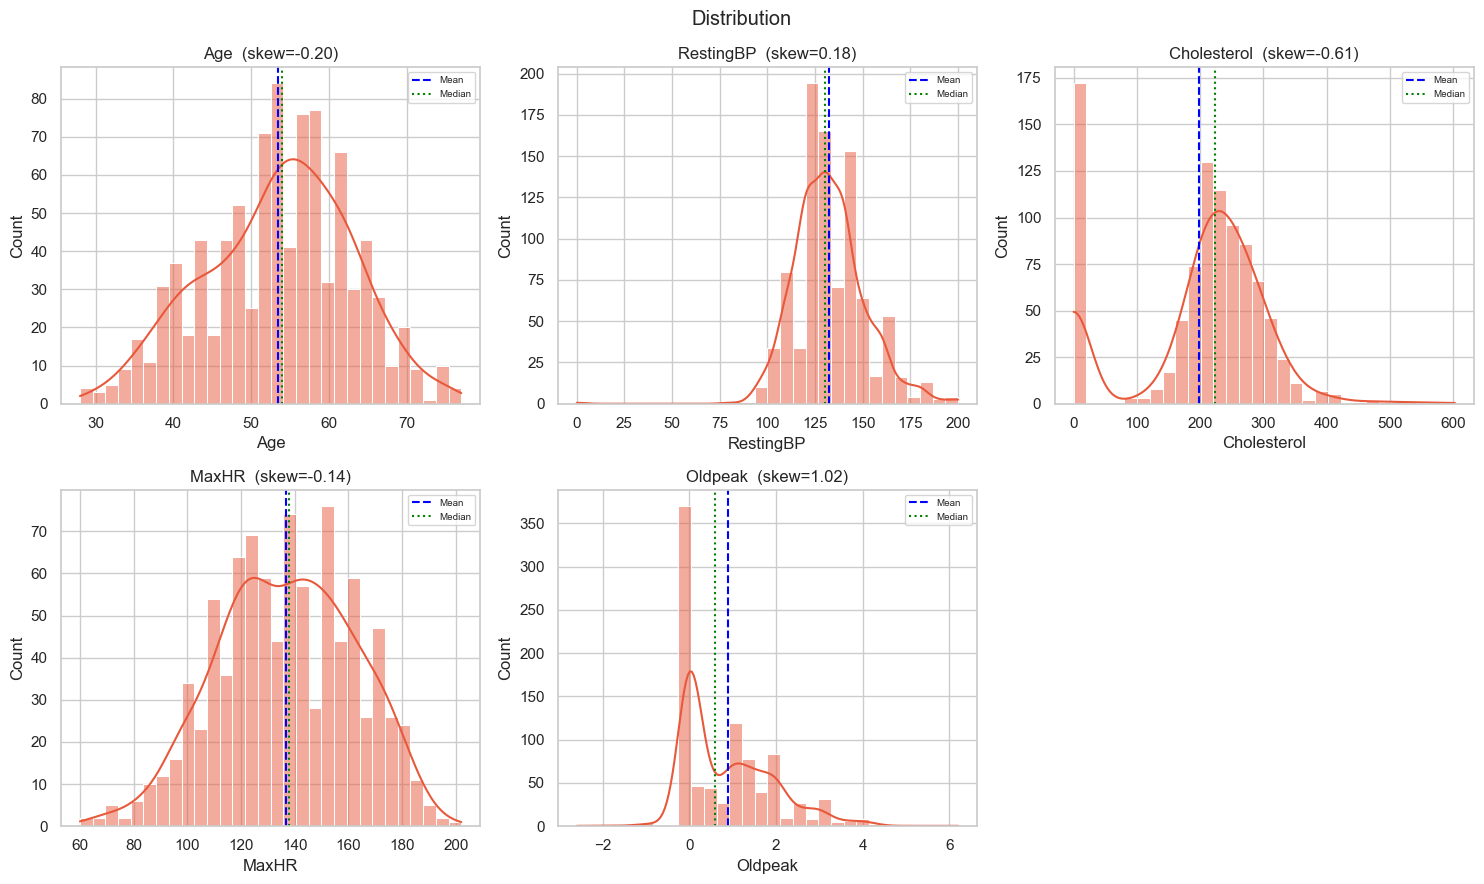

skewness:
  Age           : -0.20  -> almost perfect
  RestingBP     : +0.18  -> almost perfect
  Cholesterol   : -0.61  -> Left-skewed
  MaxHR         : -0.14  -> almost perfect
  Oldpeak       : +1.02  -> Right-skewed


In [86]:
num_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribution')

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, bins=30, color='#E8593C',
                 edgecolor='white', ax=ax)
    ax.axvline(df[col].mean(),   color='blue', ls='--', lw=1.5, label='Mean')
    ax.axvline(df[col].median(), color='green',ls=':',  lw=1.5, label='Median')
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})')
    ax.legend(fontsize=7)

fig.delaxes(axes.flatten()[-1])
plt.tight_layout()
plt.show()

print('skewness:')
for col in num_cols:
    s = df[col].skew()
    note = 'Right-skewed' if s>0.5 else 'Left-skewed' if s<-0.5 else 'almost perfect'
    print(f'  {col:<14}: {s:+.2f}  -> {note}')


# 4. Bivariate

Phan bo Target (HeartDisease):
              so_luong  ti_le
HeartDisease                 
1                  508  55.3%
0                  410  44.7%


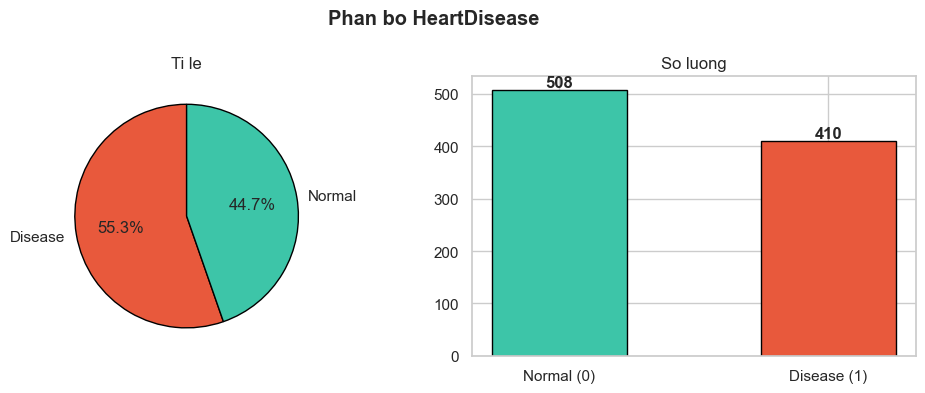

In [87]:
# --- Target distribution ---
counts = df['HeartDisease'].value_counts()
ratios = df['HeartDisease'].value_counts(normalize=True)
print('Phan bo Target (HeartDisease):')
print(pd.DataFrame({'so_luong': counts, 'ti_le': ratios.map('{:.1%}'.format)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Phan bo HeartDisease', fontweight='bold')

axes[0].pie([counts[1]/len(df)*100, counts[0]/len(df)*100],
            labels=['Disease','Normal'], autopct='%1.1f%%',
            colors=COLORS[::-1], startangle=90,
            wedgeprops={'edgecolor':'black'})
axes[0].set_title('Ti le')

bars = axes[1].bar(['Normal (0)','Disease (1)'], counts.values,
                   color=COLORS, edgecolor='black', width=0.5)
for bar, n in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(n), ha='center', fontweight='bold')
axes[1].set_title('So luong')
plt.tight_layout(); plt.show()


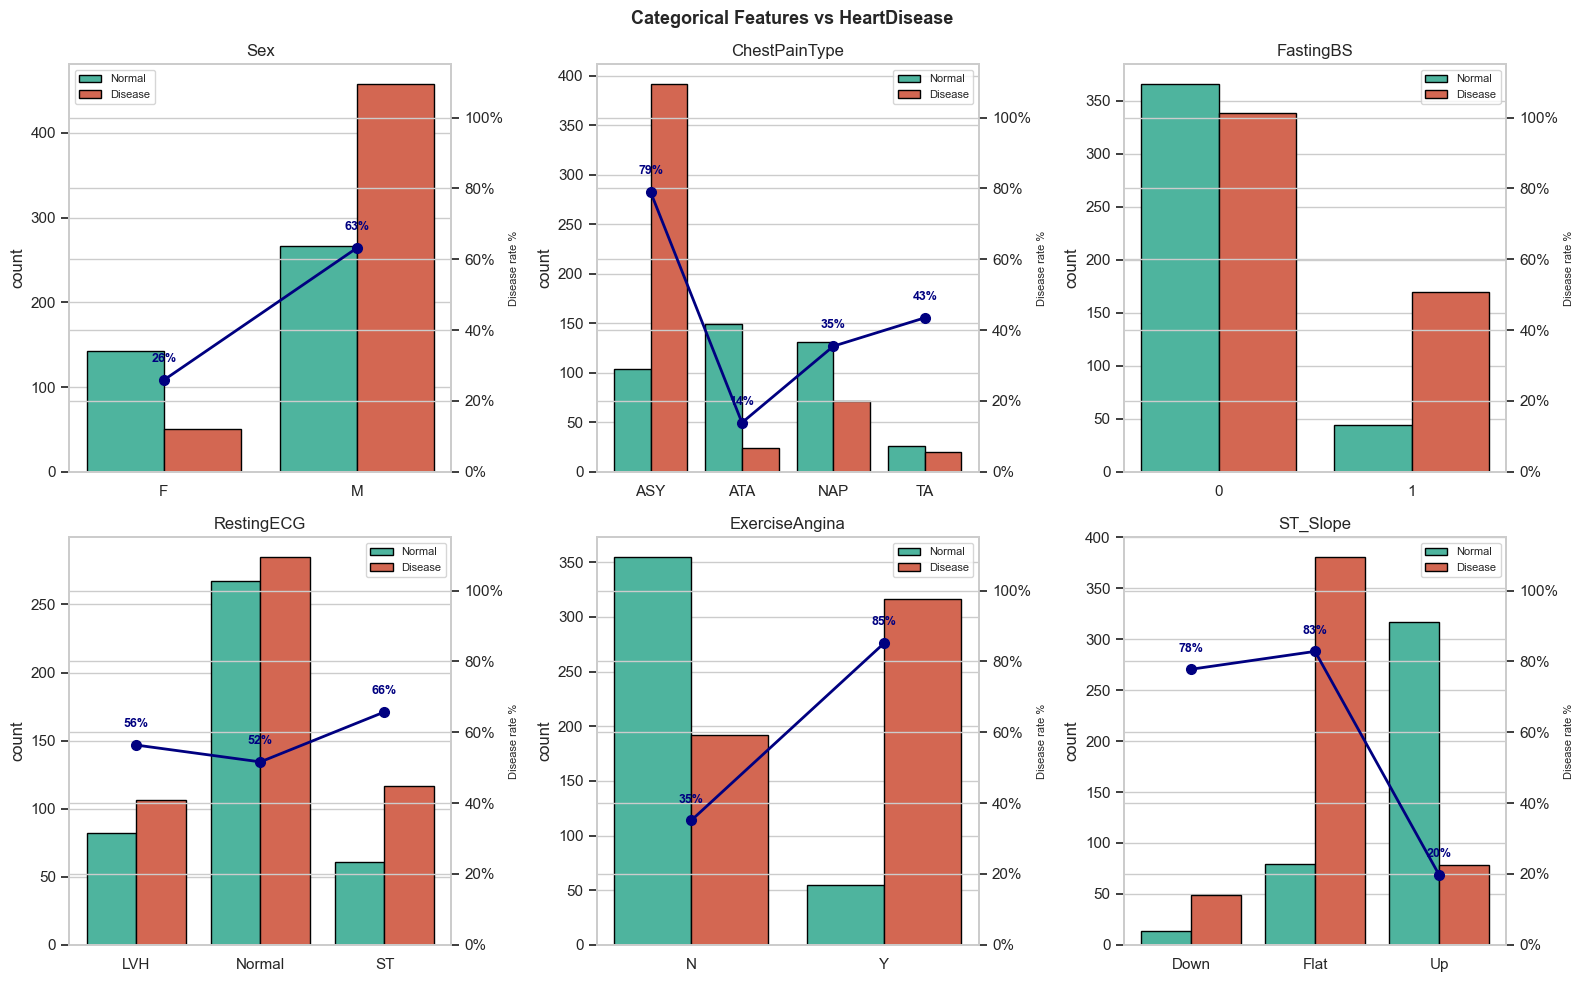

In [88]:
# --- Categorical vs Target ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Features vs HeartDisease', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    order = sorted(df[col].astype(str).unique())
    sns.countplot(x=col, hue='HeartDisease', data=df, order=order,
                  palette={0:COLORS[0],1:COLORS[1]}, edgecolor='black', ax=ax)

    # Disease rate % tren moi category
    ax2 = ax.twinx()
    rate = df.groupby(col)['HeartDisease'].mean().reindex(order).values
    ax2.plot(range(len(order)), rate, color='navy',
             marker='o', lw=2, markersize=7, zorder=5)
    for xi, val in enumerate(rate):
        if not np.isnan(val):
            ax2.annotate(f'{val:.0%}', (xi, val+0.05),
                         ha='center', fontsize=9, color='navy', fontweight='bold')
    ax2.set_ylim(0, 1.15); ax2.set_ylabel('Disease rate %', fontsize=8)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
    ax.set_title(col); ax.set_xlabel('')
    ax.legend(['Normal','Disease'], fontsize=8)

plt.tight_layout(); plt.show()


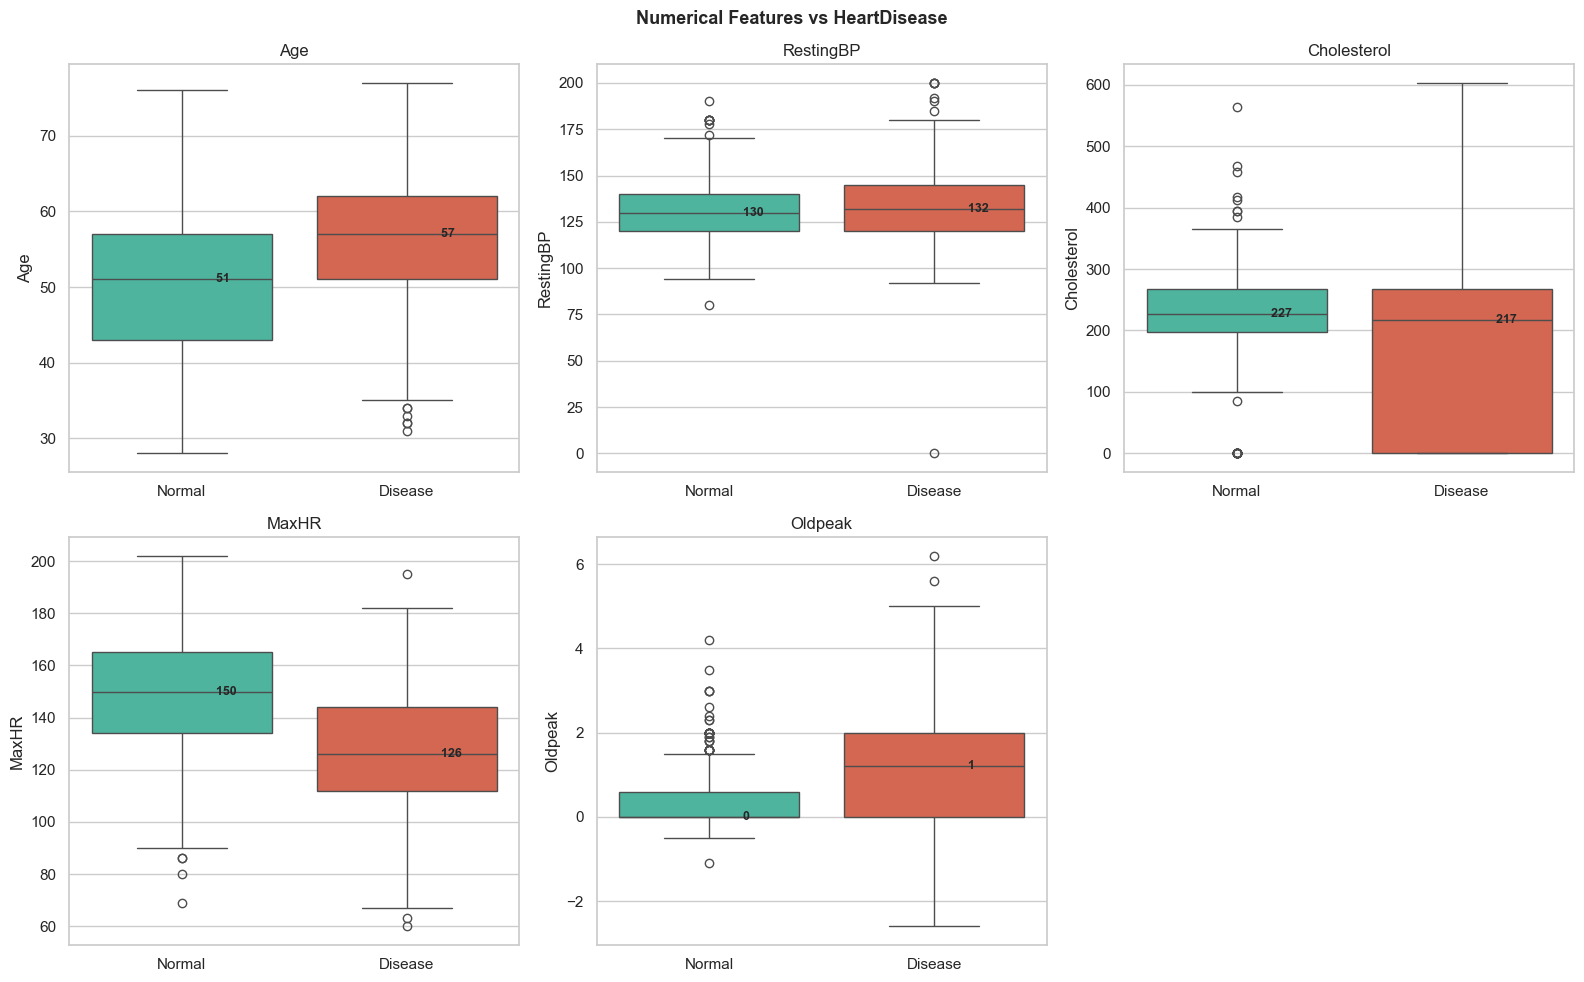

In [89]:
# --- Numerical vs Target ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Numerical Features vs HeartDisease', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='HeartDisease', y=col,
                hue='HeartDisease',
                palette={0:COLORS[0],1:COLORS[1]},
                legend=False, ax=ax)
    for cv, xp in [(0,0),(1,1)]:
        med = df[df['HeartDisease']==cv][col].median()
        ax.text(xp+0.12, med, f'  {med:.0f}',
                va='center', fontsize=9, fontweight='bold')
    ax.set_title(col)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Normal','Disease'])
    ax.set_xlabel('')

fig.delaxes(axes.flatten()[-1])
plt.tight_layout(); plt.show()


# 5. Correlation

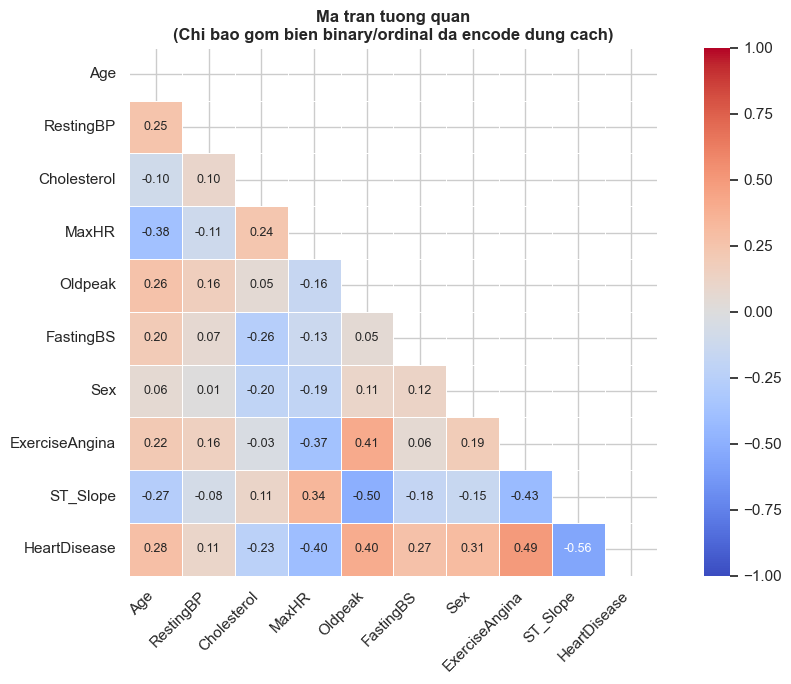

Tuong quan voi HeartDisease (sap xep theo |r|):
ST_Slope          0.558771
ExerciseAngina    0.494282
Oldpeak           0.403951
MaxHR             0.400421
Sex               0.305445
Age               0.282039
FastingBS         0.267291
Cholesterol       0.232741
RestingBP         0.107589


In [92]:
df_corr = df.copy()

# Encode dung: binary + ordinal
df_corr['Sex_enc']            = (df_corr['Sex'] == 'M').astype(int)
df_corr['ExerciseAngina_enc'] = (df_corr['ExerciseAngina'] == 'Y').astype(int)
df_corr['ST_Slope_enc']       = df_corr['ST_Slope'].map({'Down':0,'Flat':1,'Up':2})

corr_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak',
             'FastingBS','Sex_enc','ExerciseAngina_enc','ST_Slope_enc','HeartDisease']

corr = df_corr[corr_cols].corr()
rename = {'Sex_enc':'Sex','ExerciseAngina_enc':'ExerciseAngina','ST_Slope_enc':'ST_Slope'}
corr = corr.rename(columns=rename, index=rename)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size':9})
plt.title('Ma tran tuong quan\n'
          '(Chi bao gom bien binary/ordinal da encode dung cach)',
          fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Tuong quan voi HeartDisease (sap xep theo |r|):')
corr_target = corr['HeartDisease'].drop('HeartDisease').abs().sort_values(ascending=False)
print(corr_target.to_string())
